In [1]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\POONAMTHAKURHP\OneDrive\Desktop\phishing url
['app.py', 'dataset.csv', 'features.py', 'phishingdetection.ipynb', 'requirements.txt']


In [3]:
import pandas as pd

df = pd.read_csv("dataset.csv")

print("Total URL:", len(df))

df.head()

Total URL: 120000


,url,url_length,domain_length,path_length,num_dots,num_hyphens,num_underscores,num_slashes,num_question_marks,num_equal_signs,...,has_double_slash,has_prefix_suffix,path_depth,is_common_tld,is_suspicious_tld,brand_impersonation,num_suspicious_words,digits_in_domain,long_domain,label
0,wbhbhks5x3.xyz,14.0,14.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0
1,athensmessenger.com/,20.0,19.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
2,https://kingerhelpservice.blogspot.com/,31.0,30.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
3,www.alibrown.co.nz/history-of-nz-flax.html,38.0,14.0,24.0,3.0,3.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,www.createafreewebsite.net/phpmysql/phpmysql_i...,58.0,22.0,36.0,2.0,0.0,1.0,2.0,0.0,0.0,...,0.0,0.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,1


In [18]:
# Check original size
start_n = len(df)

# Clean URL
df['url'] = df['url'].astype(str).str.strip()

# Remove empty/very short URLs
df = df[df['url'].str.len() > 3].copy()

malformed = start_n - len(df)

# Remove duplicate URLs
before = len(df)
df = df.drop_duplicates(subset=['url']).reset_index(drop=True)

dupes = before - len(df)

print('===== CLEANING REPORT =====')
print('Starting rows      :', start_n)
print('Malformed removed  :', malformed)
print('Duplicates removed :', dupes)
print('Final rows         :', len(df))

print('\nLabel distribution:')
print(df['label'].value_counts())

===== CLEANING REPORT =====
Starting rows      : 120000
Malformed removed  : 0
Duplicates removed : 0
Final rows         : 120000

Label distribution:
label
0    60000
1    60000
Name: count, dtype: int64


In [8]:
from tranco import Tranco
import pandas as pd

t = Tranco(cache=True, cache_dir='.tranco')
tranco_list = t.list()
top_domains = tranco_list.top(30000)

print('Fetched', len(top_domains), 'Tranco domains')
print('Examples:', top_domains[:5])

# bare domains (no scheme) — scheme is unreliable in this dataset
tranco_df = pd.DataFrame({'url': top_domains, 'label': 0})

df = pd.concat([df, tranco_df], ignore_index=True)
df = df.drop_duplicates(subset=['url']).reset_index(drop=True)

print('\nAfter adding Tranco:')
print('Total:', len(df), '| Phishing:', int(df.label.sum()), '| Benign:', int((df.label==0).sum()))

Fetched 30000 Tranco domains
Examples: ['google.com', 'cloudflare.com', 'facebook.com', 'gstatic.com', 'googleapis.com']

After adding Tranco:
Total: 30000 | Phishing: 0 | Benign: 30000


In [9]:
SAMPLE = 120000          # a bit larger to include Tranco variety
if SAMPLE and len(df) > SAMPLE:
    per = SAMPLE // 2
    p = df[df.label == 1].sample(min(per, (df.label==1).sum()), random_state=42)
    l = df[df.label == 0].sample(min(per, (df.label==0).sum()), random_state=42)
    df = pd.concat([p, l]).sample(frac=1, random_state=42).reset_index(drop=True)
print('Using', len(df), 'URLs | Phishing:', int(df.label.sum()), '| Benign:', int((df.label==0).sum()))

Using 30000 URLs | Phishing: 0 | Benign: 30000


In [10]:

import re, math
from urllib.parse import urlparse
from tqdm import tqdm
tqdm.pandas()

def entropy(s):
    if not s: return 0.0
    fr = {}
    for c in s: fr[c] = fr.get(c, 0) + 1
    n = len(s)
    return -sum((v/n)*math.log2(v/n) for v in fr.values())

SUSP = ['login','secure','account','update','verify','banking','confirm','password',
        'signin','paypal','ebay','amazon','support','service','free','lucky','bonus','click','webscr']
BRANDS = ['paypal','amazon','ebay','apple','microsoft','netflix','facebook',
          'google','bank','instagram','whatsapp','outlook','office365']
SHORT = ['bit.ly','tinyurl','goo.gl','t.co','ow.ly','is.gd','cutt.ly']
CT = ['.com','.org','.net','.edu','.gov']
ST = ['.xyz','.tk','.ml','.ga','.cf','.gq','.top','.click','.link','.online','.site','.work']

def _normalise(url):
    u = str(url).strip().lower()
    u = re.sub(r'^https?://', '', u)
    u = re.sub(r'^www\.', '', u)
    return u

def feats(url):
    norm = _normalise(url)
    parts = norm.split('/', 1)
    d = parts[0]
    pa = '/' + parts[1] if len(parts) > 1 else ''
    u = norm
    f = {}
    f['url_length']=len(u); f['domain_length']=len(d); f['path_length']=len(pa)
    f['num_dots']=u.count('.'); f['num_hyphens']=u.count('-'); f['num_underscores']=u.count('_')
    f['num_slashes']=u.count('/'); f['num_question_marks']=u.count('?'); f['num_equal_signs']=u.count('=')
    f['num_at_signs']=u.count('@'); f['num_ampersands']=u.count('&'); f['num_percent']=u.count('%')
    f['num_digits']=sum(c.isdigit() for c in u); f['num_subdomains']=max(0, d.count('.')-1)
    f['url_entropy']=round(entropy(u),4); f['domain_entropy']=round(entropy(d),4)
    f['digit_ratio']=round(f['num_digits']/max(len(u),1),4)
    host = d.split(':')[0]
    f['has_ip']=int(bool(re.match(r'^\d{1,3}(\.\d{1,3}){3}$', host)))
    f['has_port']=int(':' in d)
    f['is_shortened']=int(any(s in d for s in SHORT))
    f['has_suspicious_word']=int(any(w in u for w in SUSP))
    f['has_double_slash']=int('//' in pa); f['has_prefix_suffix']=int('-' in d)
    f['path_depth']=len([x for x in pa.split('/') if x])
    tld = '.'+d.split('.')[-1] if '.' in d else ''
    f['is_common_tld']=int(tld in CT); f['is_suspicious_tld']=int(tld in ST)
    f['brand_impersonation']=int(any(b in u and not d.endswith(b+'.com') for b in BRANDS))
    f['num_suspicious_words']=sum(1 for w in SUSP if w in u)
    f['digits_in_domain']=sum(c.isdigit() for c in d)
    f['long_domain']=int(len(d) > 30)
    return f

fx = df['url'].progress_apply(lambda u: pd.Series(feats(u)))
data = pd.concat([fx, df['label']], axis=1)
print('Feature matrix:', data.shape)
data.head()

100%|██████████| 30000/30000 [00:16<00:00, 1818.44it/s]

Feature matrix: (30000, 31)


,url_length,domain_length,path_length,num_dots,num_hyphens,num_underscores,num_slashes,num_question_marks,num_equal_signs,num_at_signs,...,has_double_slash,has_prefix_suffix,path_depth,is_common_tld,is_suspicious_tld,brand_impersonation,num_suspicious_words,digits_in_domain,long_domain,label
0,10.0,10.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
1,14.0,14.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
2,12.0,12.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
3,11.0,11.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
4,14.0,14.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0


In [20]:
from sklearn.model_selection import train_test_split

X = df.drop(['url', 'label'], axis=1)
y = df['label']

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", Xtr.shape)
print("Testing data:", Xte.shape)

print("\nTraining labels:")
print(ytr.value_counts())

print("\nTesting labels:")
print(yte.value_counts())

Training data: (96000, 30)
Testing data: (24000, 30)

Training labels:
label
0    48000
1    48000
Name: count, dtype: int64

Testing labels:
label
1    12000
0    12000
Name: count, dtype: int64


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr = Pipeline([('s', StandardScaler()), ('c', LogisticRegression(max_iter=1000))])
lr.fit(Xtr, ytr)
all_results.append(score('Logistic Regression', lr))


===== Logistic Regression =====
Accuracy : 0.6958
Precision: 0.6566
Recall   : 0.821
F1       : 0.7297
ROC-AUC  : 0.7479


In [22]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(Xtr, ytr)
all_results.append(score('Random Forest', rf))


===== Random Forest =====
Accuracy : 0.826
Precision: 0.8052
Recall   : 0.86
F1       : 0.8317
ROC-AUC  : 0.9083


In [24]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gb.fit(Xtr, ytr)

all_results.append(score('Gradient Boosting', gb))


===== Gradient Boosting =====
Accuracy : 0.804
Precision: 0.79
Recall   : 0.8281
F1       : 0.8086
ROC-AUC  : 0.889


In [25]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=150, max_depth=7, learning_rate=0.1,
                    random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(Xtr, ytr)
all_results.append(score('XGBoost', xgb))


===== XGBoost =====
Accuracy : 0.8266
Precision: 0.8093
Recall   : 0.8545
F1       : 0.8313
ROC-AUC  : 0.9082


In [26]:
rdf = pd.DataFrame(all_results).set_index('Model')
print('===== MODEL COMPARISON =====')
print(rdf.to_string())

best_name = rdf['F1'].idxmax()
best_model = {'Logistic Regression':lr, 'Random Forest':rf,
              'Gradient Boosting':gb, 'XGBoost':xgb}[best_name]
print('\nBest model:', best_name)
rdf

===== MODEL COMPARISON =====
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.6958     0.6566  0.8210  0.7297   0.7479
Random Forest          0.8260     0.8052  0.8600  0.8317   0.9083
Gradient Boosting      0.8040     0.7900  0.8281  0.8086   0.8890
Gradient Boosting      0.8040     0.7900  0.8281  0.8086   0.8890
XGBoost                0.8266     0.8093  0.8545  0.8313   0.9082

Best model: Random Forest


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.6958,0.6566,0.8210,0.7297,0.7479
Random Forest,0.8260,0.8052,0.8600,0.8317,0.9083
Gradient Boosting,0.8040,0.7900,0.8281,0.8086,0.8890
Gradient Boosting,0.8040,0.7900,0.8281,0.8086,0.8890
XGBoost,0.8266,0.8093,0.8545,0.8313,0.9082


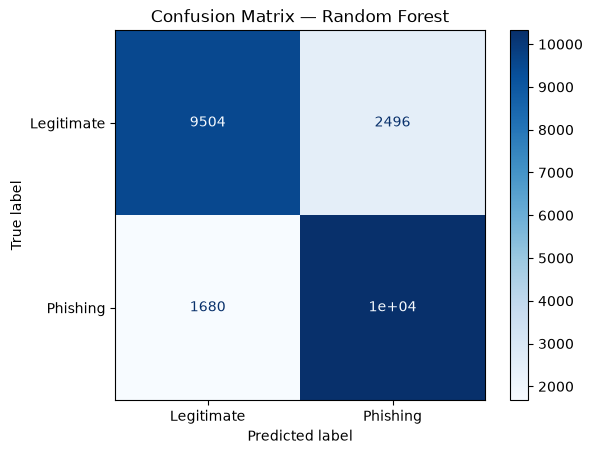

              precision    recall  f1-score   support

  Legitimate       0.85      0.79      0.82     12000
    Phishing       0.81      0.86      0.83     12000

    accuracy                           0.83     24000
   macro avg       0.83      0.83      0.83     24000
weighted avg       0.83      0.83      0.83     24000



In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

pred = best_model.predict(Xte)
ConfusionMatrixDisplay(confusion_matrix(yte, pred),
    display_labels=['Legitimate','Phishing']).plot(cmap='Blues')
plt.title('Confusion Matrix — ' + best_name); plt.show()
print(classification_report(yte, pred, target_names=['Legitimate','Phishing']))

In [29]:
cols = Xtr.columns.tolist()
print(cols)

['url_length', 'domain_length', 'path_length', 'num_dots', 'num_hyphens', 'num_underscores', 'num_slashes', 'num_question_marks', 'num_equal_signs', 'num_at_signs', 'num_ampersands', 'num_percent', 'num_digits', 'num_subdomains', 'url_entropy', 'domain_entropy', 'digit_ratio', 'has_ip', 'has_port', 'is_shortened', 'has_suspicious_word', 'has_double_slash', 'has_prefix_suffix', 'path_depth', 'is_common_tld', 'is_suspicious_tld', 'brand_impersonation', 'num_suspicious_words', 'digits_in_domain', 'long_domain']


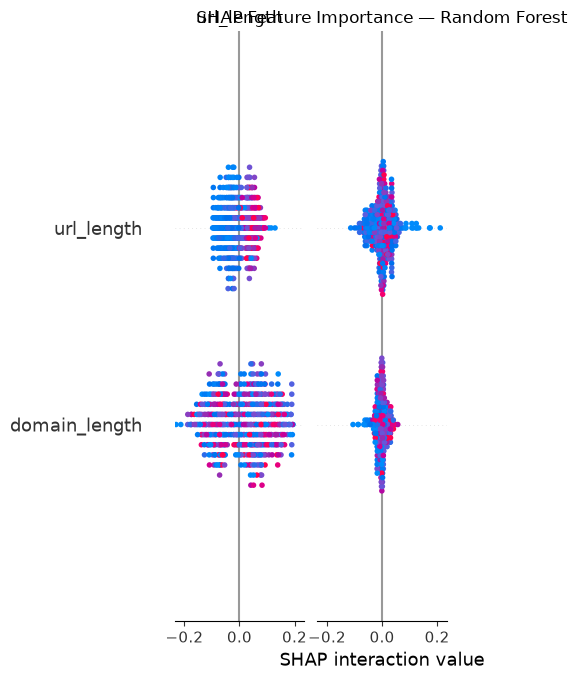

In [30]:
import shap
import matplotlib.pyplot as plt

if best_name in ('Random Forest', 'Gradient Boosting', 'XGBoost'):

    s = Xte.sample(min(500, len(Xte)), random_state=42)

    ex = shap.TreeExplainer(best_model)

    sv = ex.shap_values(s, check_additivity=False)

    if isinstance(sv, list):
        sv = sv[1]

    shap.summary_plot(
        sv,
        s,
        feature_names=s.columns,
        plot_type='bar',
        show=False
    )

    plt.title('SHAP Feature Importance — ' + best_name)
    plt.show()

c:\Users\POONAMTHAKURHP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


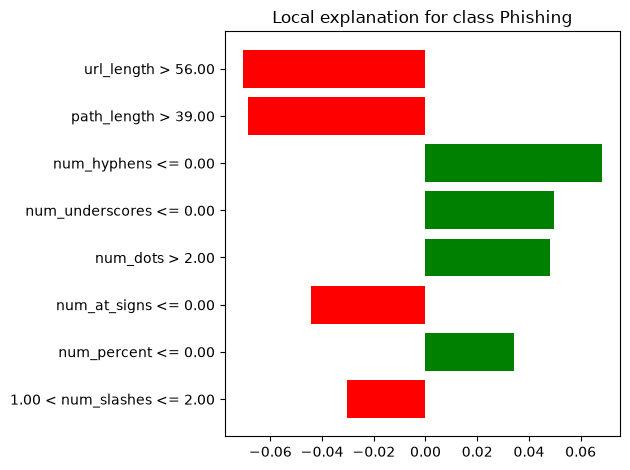

True label: Phishing


In [31]:
from lime.lime_tabular import LimeTabularExplainer

lime_ex = LimeTabularExplainer(Xtr.values, feature_names=cols,
                               class_names=['Legitimate','Phishing'],
                               mode='classification')
i = 0   # change to explain a different test URL
exp = lime_ex.explain_instance(Xte.values[i], best_model.predict_proba, num_features=8)
exp.as_pyplot_figure(); plt.tight_layout(); plt.show()
print('True label:', 'Phishing' if yte.values[i]==1 else 'Legitimate')

In [32]:
n = len(X); b = n // 3
b1 = (X.iloc[:b], y.iloc[:b])
rf_a = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_a.fit(*b1)

rows = []
for i, sl in enumerate([slice(b, 2*b), slice(2*b, n)], start=2):
    bx, by = X.iloc[sl], y.iloc[sl]
    if by.nunique() < 2: continue
    f_before = round(f1_score(by, rf_a.predict(bx)), 4)
    rf_a.fit(pd.concat([b1[0], bx]), pd.concat([b1[1], by]))
    f_after = round(f1_score(by, rf_a.predict(bx)), 4)
    rows.append({'Batch':f'Batch {i}','F1 static':f_before,
                 'F1 retrained':f_after,'Change':round(f_after-f_before,4)})

print('===== ADAPTIVE LEARNING (RQ1) =====')
print(pd.DataFrame(rows).to_string(index=False))

===== ADAPTIVE LEARNING (RQ1) =====
  Batch  F1 static  F1 retrained  Change
Batch 2     0.8309        0.8781  0.0472
Batch 3     0.8331        0.8803  0.0472


In [33]:
import pickle

# Save best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'model_name': best_name,
        'feature_cols': Xtr.columns.tolist()
    }, f)

# Save dataset
df.to_csv('dataset.csv', index=False)

print("best_model.pkl saved successfully!")
print("dataset.csv saved successfully!")

best_model.pkl saved successfully!
dataset.csv saved successfully!


In [34]:
for d in ['google.com','facebook.com','wikipedia.org']:
    print(d, ':', d in df['url'].values or ('https://www.'+d) in df['url'].values)

google.com : False
facebook.com : False
wikipedia.org : False
